In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/datasets/BCRSD.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv(file_path, keep_default_na=False)

In [6]:
df.shape

(30000, 47)

In [7]:
df.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Menopausal_Status,Age_First_Menstruation,Age_First_Pregnancy,Parity,...,Mammography_BIRADS,Ultrasound_Result,MRI_Result,Ki67_Index,HER2_Status,ER_Status,PR_Status,Genomic_Risk_Score,Breast_Cancer_Risk,Cancer_Severity
0,PT_00001,58,Female,171.2,70.8,24.15,Post,12,0,0,...,6,Highly Suggestive of Malignancy,Highly Suggestive of Malignancy,71.7,Positive,Positive,Positive,100.0,High,Stage IV
1,PT_00002,51,Female,147.3,47.5,21.88,Post,10,33,3,...,1,Normal,Normal,3.7,Not Applicable,Not Applicable,Not Applicable,15.6,Moderate,No Cancer
2,PT_00003,60,Female,166.5,67.6,24.40,Post,11,26,2,...,4,Suspicious,Suspicious,23.3,Negative,Positive,Positive,30.5,Moderate,Stage I
3,PT_00004,71,Female,169.2,74.6,26.06,Post,12,32,2,...,2,Normal,Benign,5.8,Not Applicable,Not Applicable,Not Applicable,14.5,Low,No Cancer
4,PT_00005,50,Female,170.0,61.4,21.26,Pre,13,24,1,...,1,Normal,Normal,7.5,Not Applicable,Not Applicable,Not Applicable,14.8,Low,No Cancer


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
BMI,0
Menopausal_Status,0
Age_First_Menstruation,0
Age_First_Pregnancy,0
Parity,0


In [10]:
df = df.drop(['Patient_ID', 'Height_cm', 'Weight_kg'], axis=1)

In [11]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})
df.rename(columns={'Gender':'is_female'}, inplace=True)

df['Menopausal_Status'] = df['Menopausal_Status'].map({'Pre': 0, 'Post': 1})
df.rename(columns={'Menopausal_Status': 'is_postmenopausal'}, inplace=True)

In [12]:
binary_cols = ['Family_History', 'BRCA_Mutation', 'Previous_Benign_Breast_Disease', 'Hormone_Replacement_Therapy', 'Oral_Contraceptive_Use', 'Diabetes', 'Hypertension', 'Previous_Radiation_Exposure']
for col in binary_cols:
  df[col] = df[col].map({'No': 0, 'Yes': 1})

In [13]:
ordinal_maps = {
    'Alcohol_Intake':    {'None': 0, 'Low': 1, 'Moderate': 2, 'High': 3},
    'Physical_Activity': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Diet_Quality':      {'Poor': 0, 'Fair': 1, 'Good': 2},
    'Stress_Level':      {'Low': 0, 'Moderate': 1, 'High': 2},
    'Breast_Density':    {'A': 0, 'B': 1, 'C': 2, 'D': 3},
}
for col, mapping in ordinal_maps.items():
  df[col] = df[col].map(mapping)

In [14]:
df = pd.get_dummies(df, columns=['Breastfeeding_History', 'Smoking_Status'], dtype=float)

In [15]:
df['Ever_Pregnant'] = (df['Age_First_Pregnancy'] > 0).astype(int)
df['Age_First_Pregnancy'] = df['Age_First_Pregnancy'].replace(0, np.nan)
df['Age_Menopause'] = df['Age_Menopause'].replace(0, np.nan)

In [16]:
df['Estrogen_Level'] = np.log1p(df['Estrogen_Level'])
df['Progesterone_Level'] = np.log1p(df['Progesterone_Level'])

In [17]:
leakage_prone_features = ["Tumor_Size_mm", "Lymph_Node_Involvement", "Mammography_BIRADS", "Ultrasound_Result", "MRI_Result", "Tumor_Location", "Tumor_Shape", "Tumor_Margin", "Calcification", "Ki67_Index", "HER2_Status", "ER_Status", "PR_Status", "Genomic_Risk_Score", "Breast_Cancer_Risk", "CA15_3", "CEA_Level"]

In [18]:
x = df.drop(columns=['Cancer_Severity'] + leakage_prone_features)
y = df['Cancer_Severity']

In [19]:
x = x.astype(float)

In [20]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


CLASS_ORDER = ['No Cancer', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']
assert list(encoder.classes_) == CLASS_ORDER, "Class order is not clinical order!"

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [22]:
imputer = SimpleImputer(strategy='median')
x_train_imp = imputer.fit_transform(x_train)
x_test_imp = imputer.transform(x_test)

In [23]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_imp)
x_test_scaled = scaler.transform(x_test_imp)

In [24]:
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [25]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(weights))

In [26]:
n_features = x_train_scaled.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(5, activation='softmax')
])

In [27]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,869 (19.02 KB)

 Trainable params: 4,869 (19.02 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
]

In [29]:
history = model.fit(x_train_scaled, y_train_cat,
                    epochs=100, batch_size=64, validation_split=0.15,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)

Epoch 1/100
319/319 - 8s - 24ms/step - accuracy: 0.2159 - loss: 1.5298 - val_accuracy: 0.4347 - val_loss: 1.3912 - learning_rate: 0.0010
Epoch 2/100
319/319 - 2s - 5ms/step - accuracy: 0.4283 - loss: 1.3539 - val_accuracy: 0.4603 - val_loss: 1.2704 - learning_rate: 0.0010
Epoch 3/100
319/319 - 2s - 5ms/step - accuracy: 0.4467 - loss: 1.3151 - val_accuracy: 0.4800 - val_loss: 1.2580 - learning_rate: 0.0010
Epoch 4/100
319/319 - 1s - 3ms/step - accuracy: 0.4588 - loss: 1.3002 - val_accuracy: 0.4697 - val_loss: 1.2505 - learning_rate: 0.0010
Epoch 5/100
319/319 - 1s - 3ms/step - accuracy: 0.4598 - loss: 1.2871 - val_accuracy: 0.4681 - val_loss: 1.2612 - learning_rate: 0.0010
Epoch 6/100
319/319 - 1s - 2ms/step - accuracy: 0.4630 - loss: 1.2835 - val_accuracy: 0.4747 - val_loss: 1.2591 - learning_rate: 0.0010
Epoch 7/100
319/319 - 1s - 3ms/step - accuracy: 0.4669 - loss: 1.2822 - val_accuracy: 0.4747 - val_loss: 1.2553 - learning_rate: 0.0010
Epoch 8/100
319/319 - 1s - 4ms/step - accuracy:

In [30]:
loss, acc = model.evaluate(x_test_scaled, y_test_cat, verbose=0)
print(f"\nTest loss: {loss:.4f} | Test accuracy: {acc:.4f}")


Test loss: 1.1964 | Test accuracy: 0.4888


In [31]:
y_pred = model.predict(x_test_scaled, verbose=0).argmax(axis=1)
print("Macro-F1:", round(f1_score(y_test, y_pred, average='macro'), 4))
print("Majority-class baseline accuracy:", round(np.mean(y_test == np.bincount(y_test).argmax()), 4))
print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

Macro-F1: 0.4317
Majority-class baseline accuracy: 0.41
              precision    recall  f1-score   support

   No Cancer      0.684     0.728     0.706      2460
     Stage I      0.312     0.267     0.288      1380
    Stage II      0.270     0.222     0.243      1020
   Stage III      0.341     0.479     0.398       720
    Stage IV      0.572     0.483     0.524       420

    accuracy                          0.489      6000
   macro avg      0.436     0.436     0.432      6000
weighted avg      0.479     0.489     0.481      6000



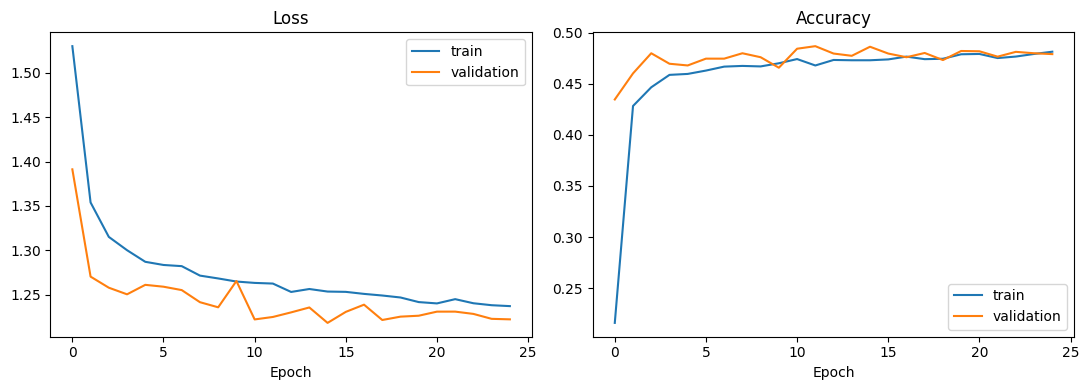

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m in zip(axes, ['loss', 'accuracy']):
    ax.plot(history.history[m], label='train')
    ax.plot(history.history['val_' + m], label='validation')
    ax.set_title(m.capitalize()); ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.savefig('learning_curves.png', dpi=150); plt.show()